## Import libraries

In [35]:
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt

import os
from astropy.table import Table
from astropy.cosmology import FlatwCDM
import emcee
import numpy as np
import corner
import scipy.optimize as op
import pandas as pd

## Data adquisition

In [52]:
def h2gdat(dpath):
    tpath = dpath + 'indat/h2data.dat'
    data = Table.read(tpath, format='ascii')

    vx = data['col4']
    vxErr = data['col5']
    vy = data['col6']
    vyErr = data['col7']
    vz = data['col2']
    vzErr = data['col3']
    return vx, vxErr, vy, vyErr, vz, vzErr

In [53]:
# Main Code
#mcd = os.path.dirname(os.path.abspath(__file__))

mcd = os.getcwd()

dpath = mcd + '/dat/'

# Reading Data
vx, vxErr, vy, vyErr, vz, vzErr = h2gdat(dpath)

In [75]:
data = {'Id': np.arange(0,189,1),
        r'L(H$\beta$)': vy,
        r'Error L(H$\beta$)': vyErr,
        r'$\sigma$': vx,
        r'Error $\sigma$': vxErr,
        r'$z$': vz,
        r'Error $z$': vzErr}
DF = pd.DataFrame(data)
DF[r'We $z$'] = (DF[r'Error $z$'] / DF[r'$z$'] ) * 100
DF

,Id,L(H$\beta$),Error L(H$\beta$),$\sigma$,Error $\sigma$,$z$,Error $z$,We $z$
0,0,-10.247740,0.057675,1.180335,0.013678,24.22000,0.130000,0.536746
1,1,-10.475930,0.061620,1.114404,0.011784,24.22000,0.130000,0.536746
2,2,-11.054385,0.057186,1.414314,0.023396,29.15000,0.100000,0.343053
3,3,-11.920568,0.052900,1.369239,0.021104,29.15000,0.100000,0.343053
4,4,-11.861371,0.060981,1.295864,0.017882,29.15000,0.100000,0.343053
...,...,...,...,...,...,...,...,...
184,184,-16.698018,0.064932,1.618346,0.020591,1.43660,0.000010,0.000691
185,185,-16.219432,0.057330,1.821057,0.024704,1.64914,0.000015,0.000902
186,186,-16.985118,0.067629,1.727295,0.035129,1.58196,0.000031,0.001954
187,187,-16.419383,0.061664,1.656334,0.018823,1.41204,0.000010,0.000682


(array([107.,   0.,   3.,   0.,  12.,  10.,  12.,   9.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          2.,   4.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.,
          6.,   0.,   3.,   0.,   5.,   2.,   0.,   3.,   3.,   3.,   1.,
          1.]),
 array([8.8000000e-03, 3.2221200e-01, 6.3562400e-01, 9.4903600e-01,
        1.2624480e+00, 1.5758600e+00, 1.8892720e+00, 2.2026840e+00,
        2.5160960e+00, 2.8295080e+00, 3.1429200e+00, 3.4563320e+00,
        3.7697440e+00, 4.0831560e+00, 4.3965680e+00, 4.7099800e+00,
        5.0233920e+00, 5.3368040e+00, 5.650216

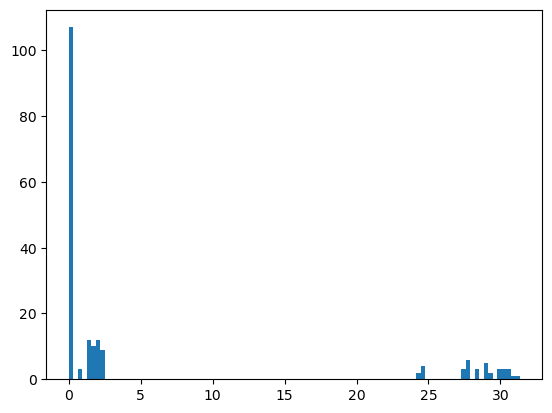

In [70]:
plt.hist(DF['$z$'], bins = 100)

In [71]:
GEHR = DF[DF['$z$'] > 10]
GEHR

,Id,L(H$\beta$),Error L(H$\beta$),$\sigma$,Error $\sigma$,$z$,Error $z$,We $z$
0,0,-10.247740,0.057675,1.180335,0.013678,24.22,0.13,0.536746
1,1,-10.475930,0.061620,1.114404,0.011784,24.22,0.13,0.536746
2,2,-11.054385,0.057186,1.414314,0.023396,29.15,0.10,0.343053
3,3,-11.920568,0.052900,1.369239,0.021104,29.15,0.10,0.343053
4,4,-11.861371,0.060981,1.295864,0.017882,29.15,0.10,0.343053
5,5,-12.088778,0.041425,1.304368,0.018221,29.15,0.10,0.343053
6,6,-11.830223,0.059269,1.302660,0.018156,29.15,0.10,0.343053
7,7,-11.319284,0.096267,1.105113,0.011487,24.58,0.10,0.406835
8,8,-11.566267,0.081529,1.010617,0.009360,24.58,0.10,0.406835
9,9,-10.755882,0.084450,1.245545,0.015869,24.58,0.10,0.406835


153

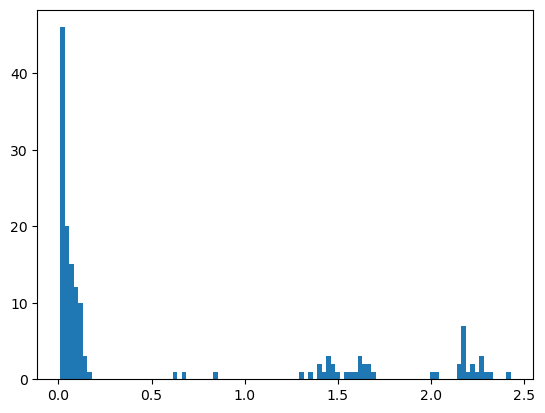

In [76]:
HIIG = DF[DF['$z$'] < 10]
plt.hist(HIIG['$z$'], bins = 100)
len(HIIG)

<BarContainer object of 153 artists>

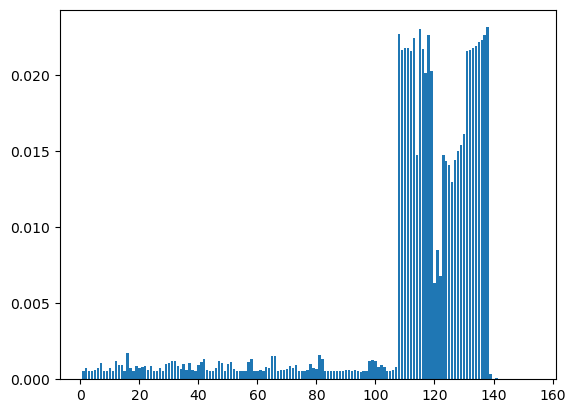

In [78]:
plt.bar(np.arange(1,154,1),HIIG[r'Error $z$'])

In [63]:
np.arange(1,154,1)

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153])

<ErrorbarContainer object of 3 artists>

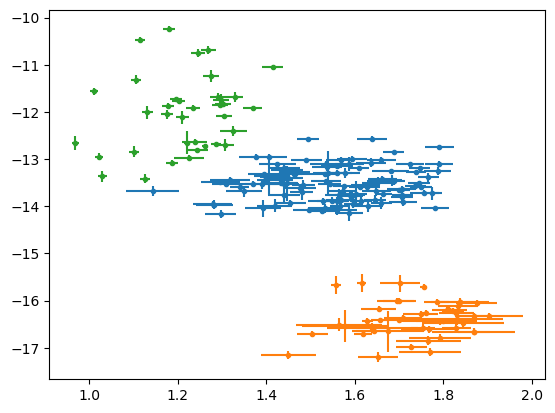

In [58]:
plt.errorbar( x = HIIG[r'$\sigma$'][HIIG['$z$'] < 0.5] ,
             y = HIIG[r'L(H$\beta$)'][HIIG['$z$'] <0.5], 
             xerr = HIIG[r'Error $\sigma$'][HIIG['$z$'] < 0.5] , 
             yerr = HIIG[r'Error L(H$\beta$)'][HIIG['$z$'] < 0.5],
            fmt = '.')
plt.errorbar( x = HIIG[r'$\sigma$'][HIIG['$z$'] > 0.5] ,
             y = HIIG[r'L(H$\beta$)'][HIIG['$z$']  > 0.5], 
             xerr = HIIG[r'Error $\sigma$'][HIIG['$z$'] > 0.5] , 
             yerr = HIIG[r'Error L(H$\beta$)'][HIIG['$z$'] > 0.5],
            fmt = '.')
plt.errorbar( x = GEHR[r'$\sigma$'] ,
             y = GEHR[r'L(H$\beta$)'], 
             xerr = GEHR[r'Error $\sigma$'] , 
             yerr = GEHR[r'Error L(H$\beta$)'],
            fmt = '.')

In [59]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0, Om, w0 = theta

    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=w0)
    ixG = np.where(z > 10)
    ixH = np.where(z < 10)

    Mum = z*0.0
    MumErr = z*0.0

    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]

    Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0
    MumErr[ixH] = (5.0/np.log(10.0))*(zerr[ixH]/z[ixH])

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt((yerr)**2 + beta**2*(xerr)**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2*W)
    llq = -0.5*xsq
    return (llq, xsq, R, Mum)
def lnprior(theta):
    alpha, beta, h0, Om, w0 = theta
    if (0.0 <= beta <= 10.0 and 20.0 <= alpha <= 40.0 and 0.5 <= h0 <= 1.0
            and 0.0 <= Om <= 1.0 and -2.0 <= w0 <= 0.0):
        return 0.0
    return -np.inf
def lnprob(theta, x, y, z, xerr, yerr, zerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, z, xerr, yerr, zerr)[0]

(array([107.,   0.,   0.,   0.,   0.,   0.,   0.,   6.,   9.,  21.]),
 array([8.800000e-03, 3.142920e+00, 6.277040e+00, 9.411160e+00,
        1.254528e+01, 1.567940e+01, 1.881352e+01, 2.194764e+01,
        2.508176e+01, 2.821588e+01, 3.135000e+01]),
 <BarContainer object of 10 artists>)

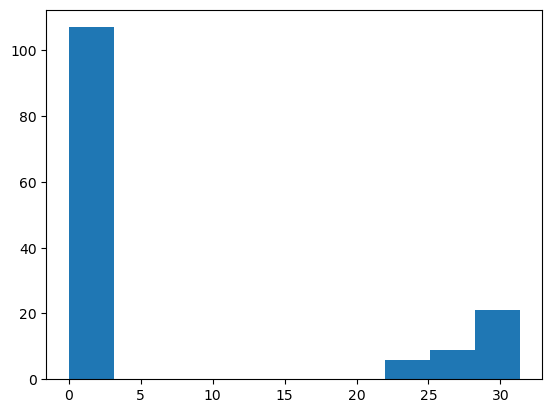

In [43]:
sample = DF[((DF['$z$'] >= 0.0) & (DF['$z$'] <= 0.5)) | (DF['$z$'] > 10)]
plt.hist(sample['$z$'], bins = 10)

In [44]:
new_sample = Table.from_pandas(sample)

In [79]:
# First guess
ialpha = 33.0
ibeta = 5.0
ih0 = 0.7
iOm = 0.3
iw0 = -1.0

In [81]:
# Maximum Likelihood
nll = lambda *args: -lnlike(*args)[0]
result = op.minimize(nll, [ialpha, ibeta, ih0],
                    args=(new_sample[r'$\sigma$'],
                        new_sample[r'L(H$\beta$)'],
                        new_sample[r'$z$'],
                        new_sample[r'Error $\sigma$'],
                        new_sample[r'Error L(H$\beta$)'],
                        new_sample[r'Error $z$']))
alpha_ml, beta_ml, h0_ml = result["x"]

print('max llq')
print(alpha_ml)
print(beta_ml)
print(h0_ml)

ValueError: not enough values to unpack (expected 5, got 3)

In [45]:

# MCMC
ndim, nwalkers = 5, 100
pos = [[ialpha, ibeta, ih0, iOm, iw0] + 1e-5*np.random.randn(ndim)
       for i in range(nwalkers)]

In [46]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob,
                                args=(new_sample[r'$\sigma$'], 
                                      new_sample[r'L(H$\beta$)'],
                                      new_sample[r'$z$'],
                                      new_sample[r'Error $\sigma$'],
                                      new_sample[r'Error L(H$\beta$)'],
                                      new_sample[r'Error $z$']),
                                threads=16)

In [47]:
# Run 100 steps as a burn-in.
pos, prob, state = sampler.run_mcmc(pos, 100)

In [48]:
# Reset the chain to remove the burn-in samples.
sampler.reset()

# Starting from the final position in the burn-in chain
sampler.run_mcmc(pos, 1000, rstate0=state)

print("Mean acceptance fraction: {0:.3f}"
      .format(np.mean(sampler.acceptance_fraction)))

samples = sampler.flatchain
lnprob = sampler.flatlnprobability

Mean acceptance fraction: 0.454


In [49]:
alpha_mcmc, beta_mcmc, h0_mcmc, Om_mcmc, w0_mcmc = map(
                                 lambda v: (v[1], v[2]-v[1], v[1]-v[0]),
                                 zip(*np.percentile(samples, [16, 50, 84],
                                                    axis=0)))

In [50]:
print('mcmc')
print(alpha_mcmc)
print(beta_mcmc)
print(h0_mcmc)
print(Om_mcmc)
print(w0_mcmc)
print(len(vx))

# Plot
path = dpath+'results/trploth0.pdf'

mcmc
(33.33345383471088, 0.1482016948860405, 0.14619380474687915)
(4.949022857566388, 0.12047284128751645, 0.12103770419685045)
(0.7310080162068309, 0.042989141013259013, 0.04047986498369027)
(0.618892211733925, 0.2735683623038173, 0.3707728787832598)
(-0.6851897368616309, 0.5050426747575447, 0.7511569744329916)
189


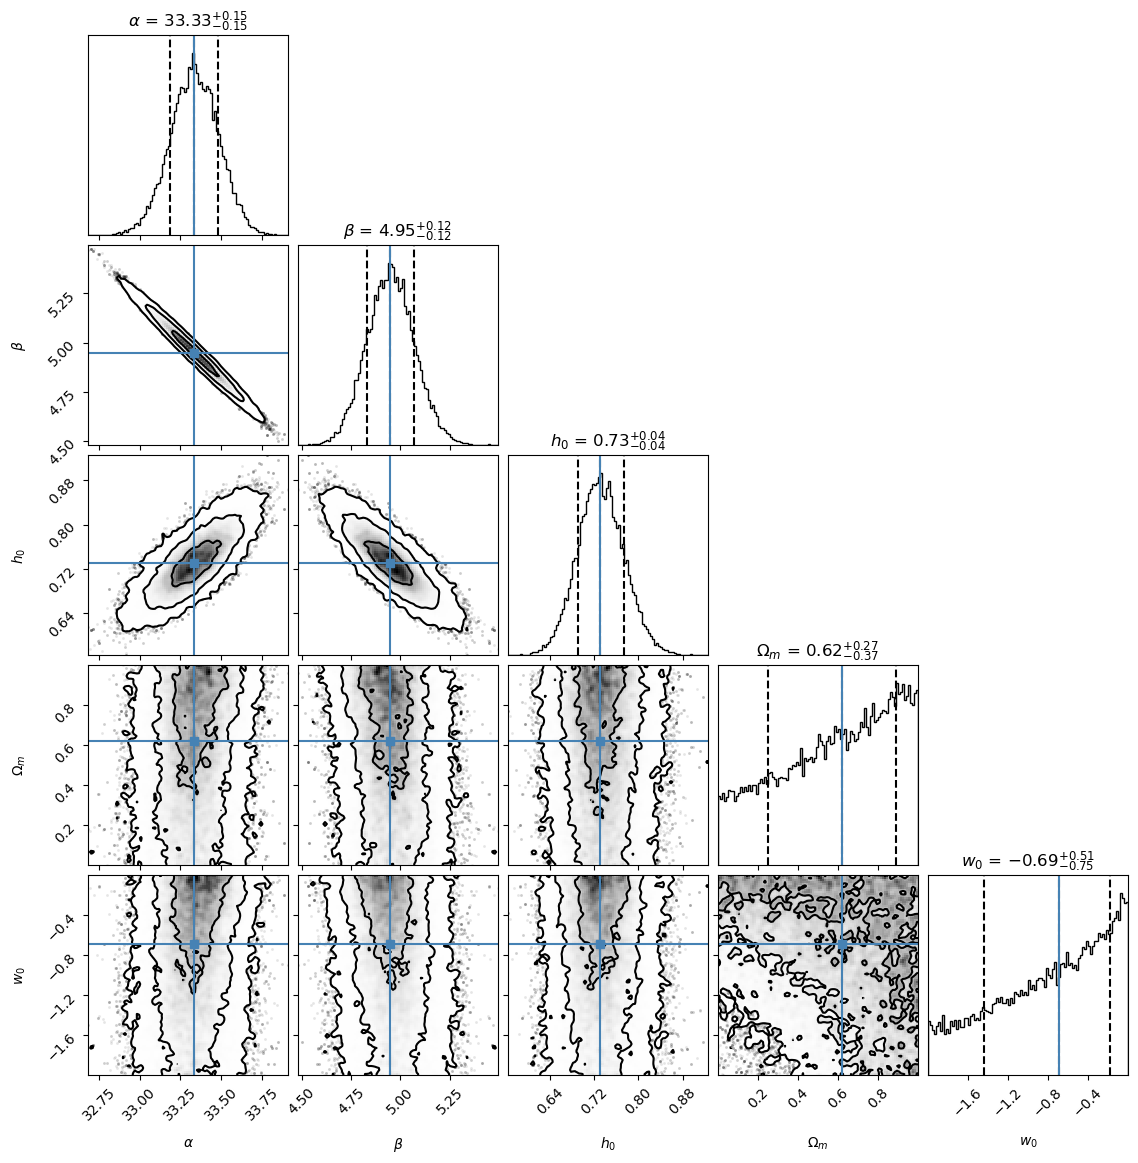

In [51]:

fig = corner.corner(samples,
                    labels=["$\\alpha$", "$\\beta$", "$h_0$", "$\Omega_m$",
                            "$w_0$"],
                    truths=[alpha_mcmc[0],  beta_mcmc[0], h0_mcmc[0],
                            Om_mcmc[0], w0_mcmc[0]],
                    quantiles=[0.16, 0.50, 0.84],
                    plot_contours='true',
                    levels=1.0 - np.exp(
                        -0.5 * np.arange(1.0, 3.1, 1.0) ** 2),
                    smooth=1.0,
                    bins=100,
                    color='black',
                    show_titles=1)
plt.savefig(path)